<div>
<img src=https://www.institutedata.com/wp-content/uploads/2019/10/iod_h_tp_primary_c.svg width="300">
</div>

# Lab 5.1
# *Logistic Regression*

## Predicting Survival on the Titanic

The Titanic sank during her maiden voyage after colliding with an iceberg (April 15, 1912). Due to a commercial decision there were insufficient lifeboats, a fact that was partially responsible for the loss 1,502 out of 2,224 passengers and crew.

The Titanic dataset incorporates many features of typical real-world problems: a mixture of continuous and discrete features, missing data, linear covariance, and an element of random chance. Predicting survival therefore involves many practical data science skills.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

%matplotlib inline

### 1. Load Data

Load the `titanic.csv` file into a DataFrame named "titanic", with index column = `PassengerId`. Display the head of the DataFrame.

In [3]:
# ANSWER
from google.colab import files
uploaded = files.upload()


titanic_csv = 'titanic_train.csv'
df=pd.read_csv(titanic_csv)

Saving titanic_train.csv to titanic_train.csv


In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup,FareGroup,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,"(18, 30]","(-0.001, 7.91]",1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,"(30, 50]","(31.0, 512.329]",1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,"(18, 30]","(7.91, 14.454]",0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,"(30, 50]","(31.0, 512.329]",1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,"(30, 50]","(7.91, 14.454]",0


Why would we want to set an index column based on `PassengerId`?

ANSWER: This column is the key to training and testing our model. We use it to partition the dataset and to test the predictions of our model against known outcomes.

<a name="datadictionary"></a>
### 2. Data Dictionary

If a data dictionary is available, it is handy to include it in the notebook for reference:

| Variable |                                 Definition | Key                                            |
|----------|-------------------------------------------:|------------------------------------------------|
| Survival | Survival                                   | 0 = No, 1 = Yes                                |
| Pclass   | Ticket class                               | 1 = 1st, 2 = 2nd, 3 = 3rd                      |
| Sex      | Sex                                        |                                                |
| Age      | Age in years                               |                                                |
| SibSp    | # of siblings / spouses aboard the Titanic |                                                |
| Parch    | # of parents / children aboard the Titanic |                                                |
| Ticket   | Ticket number                              |                                                |
| Fare     | Passenger fare                             |                                                |
| Cabin    | Cabin number                               |                                                |
| Embarked | Port of Embarkation                        | C = Cherbourg, Q = Queenstown, S = Southampton |

### 2. EDA

Explore dataset. Find features to predict `Survived`.

In [4]:
# ANSWER
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


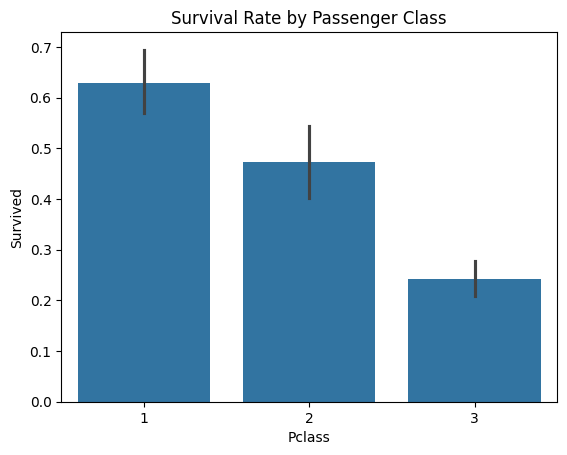

In [6]:
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Passenger Class')
plt.show()

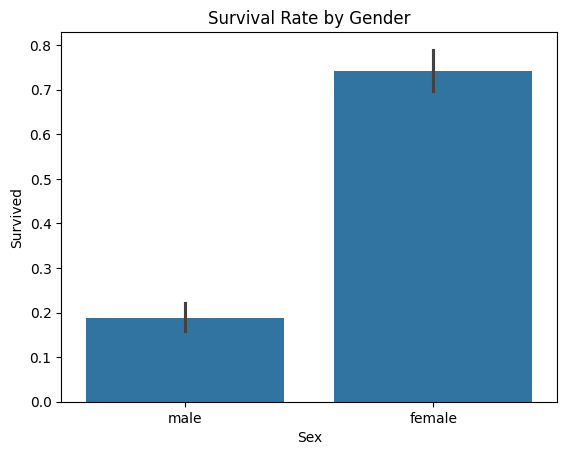

In [7]:
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Gender')
plt.show()

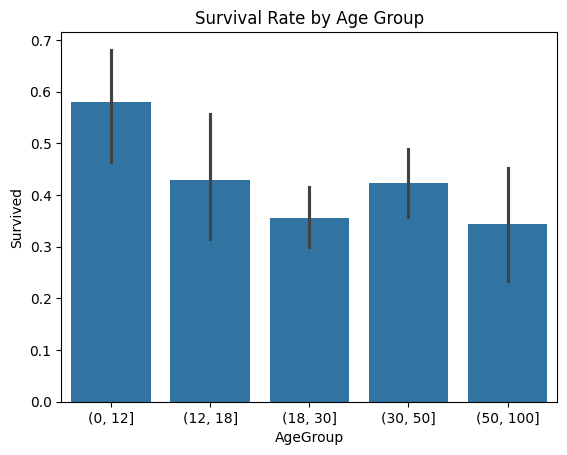

In [8]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 30, 50, 100])
sns.barplot(x='AgeGroup', y='Survived', data=df)
plt.title('Survival Rate by Age Group')
plt.show()

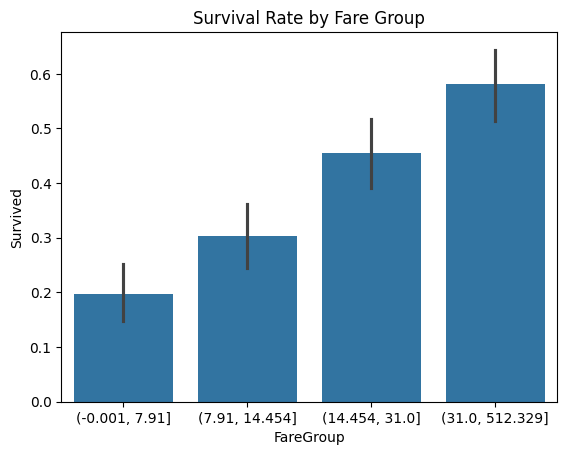

In [9]:
df['FareGroup'] = pd.qcut(df['Fare'], 4)
sns.barplot(x='FareGroup', y='Survived', data=df)
plt.title('Survival Rate by Fare Group')
plt.show()

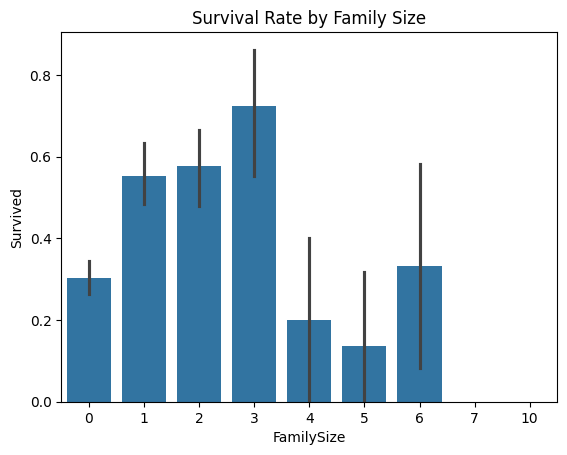

In [10]:
df['FamilySize'] = df['SibSp'] + df['Parch']
sns.barplot(x='FamilySize', y='Survived', data=df)
plt.title('Survival Rate by Family Size')
plt.show()

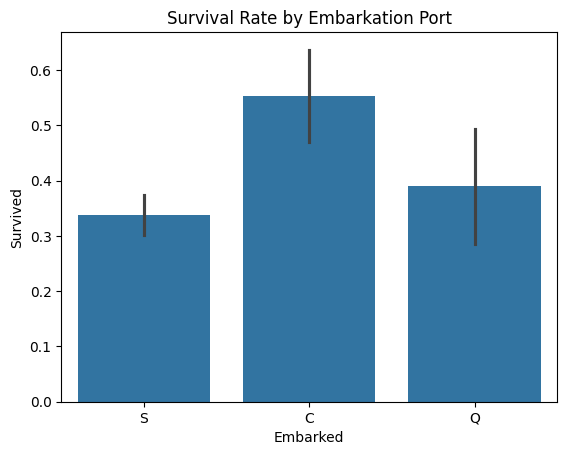

In [11]:
sns.barplot(x='Embarked', y='Survived', data=df)
plt.title('Survival Rate by Embarkation Port')
plt.show()

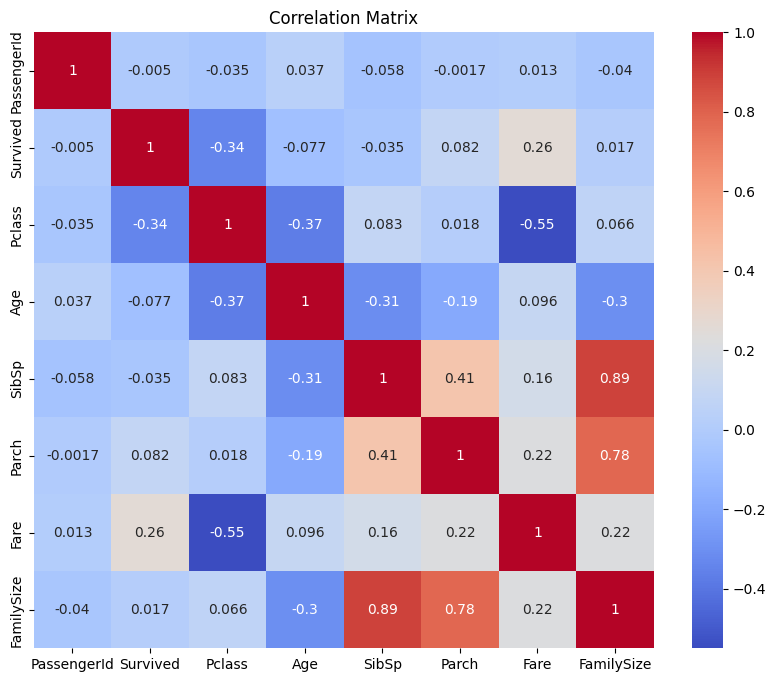

In [12]:
# Calculate correlations
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### 3. Numerical Predictors Only

#### 3.1. Set Target and Features

To begin, let's try a model based on the passenger class (`Pclass`) and parents/children features (`Parch`):

In [13]:
# Define target variable y
y = df['Survived']
# Select initial features
features = ['Pclass', 'Parch']
X = df[features]

In [14]:
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (891, 2)
Target shape: (891,)


#### 3.2 Split

Split the data into training and testing subsets:

- Use `random_state` = 1

In [42]:
# ANSWER
from sklearn.model_selection import train_test_split

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.33, random_state=1)

print(f"Training set: {X_train.shape}, {y_train.shape}")
print(f"Validation set: {X_val.shape}, {y_val.shape}")





Training set: (596, 6), (596,)
Validation set: (295, 6), (295,)


#### 3.3. Build Model

Prepare a model by creating an instance of the `LogisticRegression` class from the `sklearn.linear_model` library:

In [43]:
# ANSWER
# Create Model
# Initialize logistic regression with common parameters
model = LogisticRegression(
    random_state=1,
    max_iter=1000,
)




Now train it on the training data subset, using the `fit` method of the model object (Nb. by default, `fit` will print the hyperparameters of the model):

In [44]:
# ANSWER
# Fit Model
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=1)

The computed coefficients are an array (`coef_`) stored in the 1st element of an array:

In [45]:
# ANSWER
# Get the coefficient array (already a 1D array for binary classification)
coefficients = model.coef_[0]  # Access first element of the 2D array

coefficients # First is Pclass and second is Parch

array([-1.13499596e+00, -4.13941908e-02, -4.22518664e-01,  7.26430191e-02,
        1.33120230e-03, -2.73907068e+00])

The computed intercept (`intercept_`) is the 1st element of another array:

In [46]:
# ANSWER
intercept = model.intercept_[0]  # Access first element of the 1D array
print(f"\nIntercept: {intercept:.4f}")


Intercept: 5.0533


We can create tuples of the predictor names and coefficients like this:

In [47]:
# ANSWER
print(set(zip(features, model.coef_[0])))

{('Pclass', np.float64(-1.1349959562371954)), ('Parch', np.float64(-0.04139419081895569))}


If we want formatted output, here is a neat way to list the coefficients by predictor:

In [48]:
for col in zip(X_train.columns, model.coef_[0]):
    print('{:<10s}  {:+.06f}'.format(col[0], col[1]))  # Nb. increase 10 for longer names

Pclass      -1.134996
Age_imputed  -0.041394
SibSp       -0.422519
Parch       +0.072643
Fare        +0.001331
Sex_male    -2.739071


This result implies that survival declines with passenger class (i.e. 1st class is highest) but increases with the number of parents or children in a group.

Let's see how well the model fit the training data. The accuracy `score` is the proportion of correct predictions:

In [49]:
# ANSWER
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions on the training data
y_train_pred = model.predict(X_train)

# Calculate accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {train_accuracy:.2%}")

Training Accuracy: 80.03%


What is the accuracy `score` for the test data?

In [50]:
# ANSWER
y_test_pred = model.predict(X_val)
test_accuracy = accuracy_score(y_val, y_test_pred)
print(f"\nTest Accuracy: {test_accuracy:.2%}")


Test Accuracy: 77.97%


What can we say about this result?

ANSWER
- Only ~2 percentage points
- The small gap between training and test accuracy suggests the model isn't overfitting significantly, which is good, as it means the model generalises reasonably well to unseen data



#### 3.4. Add `AGE` as Feature

Let's include `Age` in the model. As we know from our EDA, this feature has many missing values. We don't want to throw away so many rows, so we will replace `NA` values with imputed values (e.g. the overall mean age):

Missing values in Age: 177 (19.9%)

After filling - Median age used: 28.0 years
Missing values after filling: 0


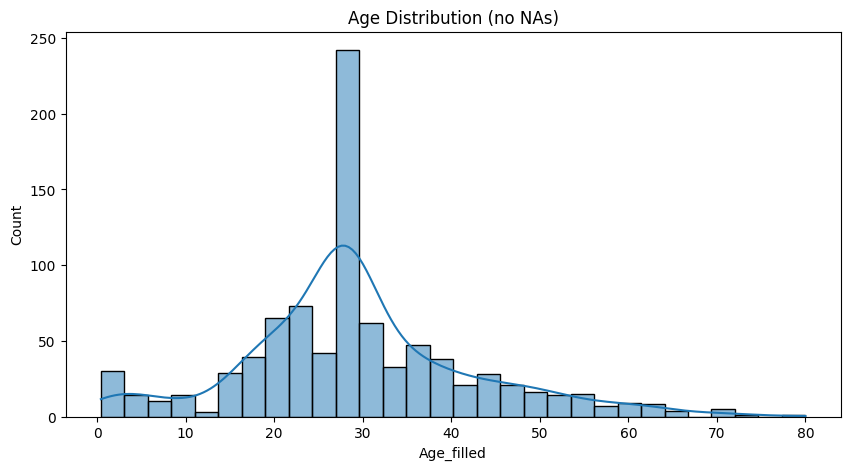

In [28]:
# ANSWER
# Check missing values in Age
print(f"Missing values in Age: {df['Age'].isna().sum()} ({df['Age'].isna().mean():.1%})")

# Fill in missing ages with median
age_median = df['Age'].median()
df['Age_filled'] = df['Age'].fillna(age_median)

# Verify
print(f"\nAfter filling - Median age used: {age_median:.1f} years")
print(f"Missing values after filling: {df['Age_filled'].isna().sum()}")

# Visualise after filling in NAs with median
plt.figure(figsize=(10, 5))
sns.histplot(df['Age_filled'], kde=True, bins=30)
plt.title('Age Distribution (no NAs)')
plt.show()


In [32]:
# Build Model
# Update predictors to include imputed age
predictors = ['Pclass', 'Sex', 'Age_imputed', 'SibSp', 'Parch', 'Fare']
X = df[predictors]

# Convert categorical variables
X = pd.get_dummies(X, columns=['Sex'], drop_first=True)

# Fit Model
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.33,
    random_state=1,
    stratify=y
)

print(f"\nTraining set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

# Initialise and train model
model = LogisticRegression(random_state=1, max_iter=1000)
model.fit(X_train, y_train)

# Score
# Evaluate
train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

print("\nModel Performance with Age:")
print(f"Training Accuracy: {accuracy_score(y_train, train_preds):.2%}")
print(f"Test Accuracy: {accuracy_score(y_test, test_preds):.2%}")


Training set shape: (596, 6)
Test set shape: (295, 6)

Model Performance with Age:
Training Accuracy: 80.87%
Test Accuracy: 78.64%


So, including age did little to reduce the variance in our model. Why might this be?

ANSWER

- Age’s effect on survival isn’t linear
- The other predictors are stronger features
- By filling in missing values as the median, the noise was reduced, which reduces meaningful variance

Let's see where the model is going wrong by showing the Confusion Matrix:

In [53]:
# ANSWER
from sklearn import metrics
y_pred_class = model.predict(X_test)
print(metrics.confusion_matrix(y_test, y_pred_class))

[[153  29]
 [ 35  78]]


Nb. Here is how `confusion_matrix` arranges its output:

In [ ]:
print(np.asarray([['TN', 'FP'], ['FN', 'TP']]))

[['TN' 'FP']
 ['FN' 'TP']]


Which type of error is more prevalent?

ANSWER: There are more false negatives than false positives. So false negatives are more prevalent

Maybe we aren't using the right cut-off value. By default, we are predicting that `Survival` = True if the probability >= 0.5, but we could use a different threshold. The ROC curve helps us decide (as well as showing us how good our predictive model really is):

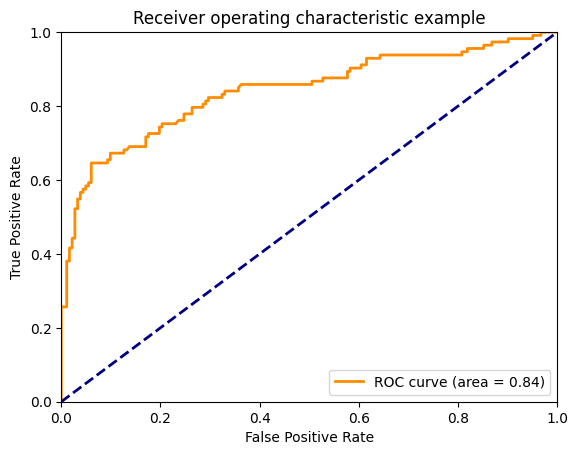

In [55]:
# Generate the prediction values for each of the test observations using predict_proba() function rather than just predict
preds = model.predict_proba(X_test)[:,1]

# Store the false positive rate(fpr), true positive rate (tpr) in vectors for use in the graph
fpr, tpr, _ = metrics.roc_curve(y_test, preds)

# Store the Area Under the Curve (AUC) so we can annotate our graph with this metric
roc_auc = metrics.auc(fpr, tpr)

# Plot the ROC Curve
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange', lw = lw, label = 'ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color = 'navy', lw = lw, linestyle = '--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc = "lower right")
plt.show()

### 4. Including Categorical Predictors

So far, we've only used numerical features for prediction. Let's convert the character features to dummy variables so we can include them in the model:

In [57]:
titanic_with_dummies = pd.get_dummies(data = df, columns = ['Sex', 'Embarked', 'Pclass'],
                                      prefix = ['Sex', 'Embarked', 'Pclass'] )
titanic_with_dummies.head()

,PassengerId,Survived,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,AgeGroup,...,Age_imputed,Age_filled,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3
0,1,0,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,"(18, 30]",...,22.0,22.0,False,True,False,False,True,False,False,True
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,"(30, 50]",...,38.0,38.0,True,False,True,False,False,True,False,False
2,3,1,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,"(18, 30]",...,26.0,26.0,True,False,False,False,True,False,False,True
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,"(30, 50]",...,35.0,35.0,True,False,False,False,True,True,False,False
4,5,0,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,"(30, 50]",...,35.0,35.0,False,True,False,False,True,False,False,True


So, this created a column for every possible value of every categorical variable. (A more compact approach would have been to reduce the number of dummy variables by one for each feature, so that the first variable from each captures two possible states.)

Now that we have data on sex, embarkation port, and passenger class we can try to improve our `Age` imputation by stratifying it by the means of groups within the passenger population:

In [58]:
titanic_with_dummies['Age'] = titanic_with_dummies[["Age", "Parch", "Sex_male", "Pclass_1", "Pclass_2"]].groupby(["Parch", "Sex_male", "Pclass_1", "Pclass_2"])["Age"].transform(lambda x: x.fillna(x.mean()))

Now train the model using the expanded set of predictors and compute the accuracy score for the test set:

In [64]:
# ANSWER
# Set Feature Both Numerical, Categorical

titanic_with_dummies['Age'] = titanic_with_dummies['Age'].fillna(titanic_with_dummies['Age'].median())
titanic_with_dummies['Fare'] = titanic_with_dummies['Fare'].fillna(titanic_with_dummies['Fare'].median())

predictors = ['Age', 'SibSp', 'Parch', 'Fare',
              'Sex_male', 'Sex_female',
              'Embarked_C', 'Embarked_Q', 'Embarked_S',
              'Pclass_1', 'Pclass_2', 'Pclass_3']

X = titanic_with_dummies[predictors]
y = titanic_with_dummies['Survived']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

# Train model
model3 = LogisticRegression(max_iter=1000, random_state=1)
model3.fit(X_train, y_train)

# Generate probability predictions
preds = model3.predict_proba(X_test)[:,1]

Plot the ROC curve for the new model:

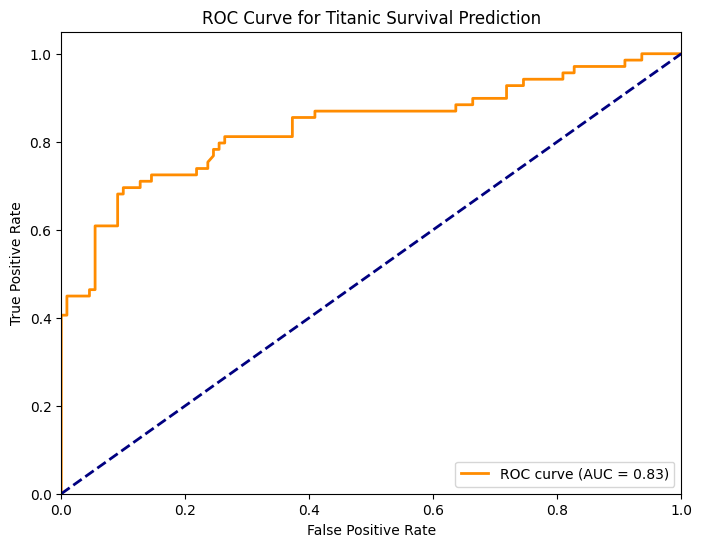


Test Accuracy: 80.45%

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.87      0.85       110
           1       0.77      0.70      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179


Top Predictive Features:
       Feature  Coefficient  Abs_Impact
4     Sex_male    -1.308023    1.308023
5   Sex_female     1.305819    1.305819
9     Pclass_1     1.194004    1.194004
11    Pclass_3    -1.180099    1.180099
1        SibSp    -0.432528    0.432528
8   Embarked_S    -0.311068    0.311068
2        Parch    -0.075977    0.075977
7   Embarked_Q     0.050887    0.050887
6   Embarked_C     0.047345    0.047345
0          Age    -0.045388    0.045388


In [63]:
# ANSWER
# ROC Curve Analysis
fpr, tpr, _ = metrics.roc_curve(y_test, preds)
roc_auc = metrics.auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Titanic Survival Prediction')
plt.legend(loc="lower right")
plt.show()

# Test set evaluation
test_preds = model3.predict(X_test)
test_accuracy = metrics.accuracy_score(y_test, test_preds)
print(f"\nTest Accuracy: {test_accuracy:.2%}")

# Classification report
print("\nClassification Report:")
print(metrics.classification_report(y_test, test_preds))

# Feature importance
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model3.coef_[0],
    'Abs_Impact': np.abs(model3.coef_[0])
}).sort_values('Abs_Impact', ascending=False)

print("\nTop Predictive Features:")
print(coefficients.head(10))

Can we improve the model by including the remaining features?

In [ ]:
# ANSWER

Yes, we can potentially improve the model by incorporating additional features, but we need to do this strategically. To save time, I have used DeepSeek to create the following code to explore the possibility of improving the model. Finally, we see the test accuracy improving by ~3 percent.

/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=15 is greater than n_features=12. All the features will be returned.
  warnings.warn(


Test Accuracy: 83.80%
              precision    recall  f1-score   support

           0       0.83      0.92      0.87       110
           1       0.84      0.71      0.77        69

    accuracy                           0.84       179
   macro avg       0.84      0.81      0.82       179
weighted avg       0.84      0.84      0.83       179



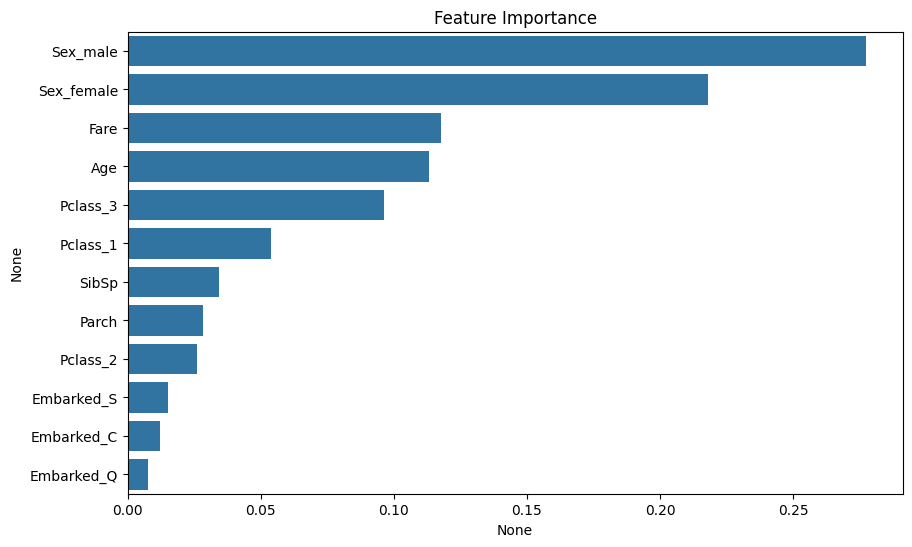

In [65]:
# Create a comprehensive feature set
all_features = ['Age', 'SibSp', 'Parch', 'Fare',
               'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S',
               'Pclass_1', 'Pclass_2', 'Pclass_3',
               'Name_Title_Mr', 'Name_Title_Mrs', 'Name_Title_Miss', 'Name_Title_Other',
               'FamilySize', 'IsAlone', 'Age*Class', 'FarePerPerson']

# Extract title from names
titanic_with_dummies['Name_Title'] = titanic_with_dummies['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
titanic_with_dummies['Name_Title'] = titanic_with_dummies['Name_Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Other')
titanic_with_dummies['Name_Title'] = titanic_with_dummies['Name_Title'].replace('Mlle', 'Miss')
titanic_with_dummies['Name_Title'] = titanic_with_dummies['Name_Title'].replace('Ms', 'Miss')
titanic_with_dummies['Name_Title'] = titanic_with_dummies['Name_Title'].replace('Mme', 'Mrs')

# Create new engineered features
titanic_with_dummies['FamilySize'] = titanic_with_dummies['SibSp'] + titanic_with_dummies['Parch'] + 1
titanic_with_dummies['IsAlone'] = (titanic_with_dummies['FamilySize'] == 1).astype(int)
titanic_with_dummies['Age*Class'] = titanic_with_dummies['Age'] * titanic_with_dummies['Pclass_3']
titanic_with_dummies['FarePerPerson'] = titanic_with_dummies['Fare'] / titanic_with_dummies['FamilySize']

# Create dummy variables for titles
titanic_with_dummies = pd.get_dummies(titanic_with_dummies, columns=['Name_Title'], prefix='Name_Title')

from sklearn.feature_selection import SelectKBest, f_classif

# Select top 15 features
selector = SelectKBest(f_classif, k=15)
X_new = selector.fit_transform(X_train, y_train)

# Get selected feature names
selected_features = X_train.columns[selector.get_support()]

from sklearn.ensemble import RandomForestClassifier

# Use selected features
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# Train Random Forest (often performs better than logistic regression)
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=1)
model.fit(X_train_selected, y_train)

# Evaluate
test_preds = model.predict(X_test_selected)
print(f"Test Accuracy: {metrics.accuracy_score(y_test, test_preds):.2%}")
print(metrics.classification_report(y_test, test_preds))

# Plot feature importance
feature_imp = pd.Series(model.feature_importances_, index=selected_features).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=feature_imp, y=feature_imp.index)
plt.title('Feature Importance')
plt.show()

## Homework

1. Remove the `random_state` parameter (if you have used), so that the data partition will be different every time, and run through the final modelling process a few times. Do the results change?

2. Use cross-validation to assess the quality of the model when overfitting is controlled. Does the accuracy improve?

3. Look at the `fpr` & `tpr` vectors for the best model.



---



---



> > > > > > > > > © 2025 Institute of Data


---



---



